# Entregable 1 — Seminario de Ciencia de Datos
## Análisis Exploratorio y Tratamiento de Datos

**Dataset:** Heart Disease Cleveland — UCI Machine Learning Repository

**Descripción general:** este dataset contiene información médica de pacientes (edad, colesterol, presión arterial, frecuencia cardíaca, entre otras variables). Nuestro objetivo es analizar la calidad de los datos e identificar posibles patrones relacionados con la presencia de enfermedad cardíaca.

**Equipo:** Jaime Alberto Alzate Marulanda · Jhon Stiven Cortes Rivera · Juan David Leyton Ruiz · Pedro Manuel Mendoza Arias · Julián Rodas González  
**Asesor:** Wilson Andrés Ramírez Ríos — Institución Universitaria Pascual Bravo · Facultad de Ingeniería (2026)

In [ ]:
# Importación de librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Librerías para imputación de datos
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge

# Evita que aparezcan warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

# Configuración básica de gráficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## I. Análisis Descriptivo y de Calidad

Primero cargamos el dataset. Hay un detalle a tener en cuenta: los nulos vienen marcados como `?` (y no como `NaN`), así que le indicamos a pandas que los trate como faltantes con `na_values='?'`.

In [ ]:
# URL del dataset tomado desde UCI
# De esta forma el notebook puede ejecutarse directamente en Colab

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Nombres de las columnas según la documentación del dataset
columnas = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# Carga del dataset
# header=None porque el archivo original no tiene encabezados
# na_values='?' permite reconocer valores faltantes

df = pd.read_csv(
    url,
    header=None,
    names=columnas,
    na_values='?'
)

# La variable "num" tiene valores entre 0 y 4
# Para facilitar el análisis se crea una variable binaria:
# 0 = no presenta enfermedad
# 1 = presenta enfermedad

df['target'] = (df['num'] > 0).astype(int)

# Dimensiones del dataset
print('Dimensiones del dataset:', df.shape)

# Primeras filas
df.head()

Dimensiones del dataset: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [ ]:
# Reviso los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
 14  target    303 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 35.6 KB


In [ ]:
# Estadísticos descriptivos de las variables numéricas
# Se muestran medidas como:
# media, desviación estándar, mínimos y máximos

df.describe().round(2)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00,1.00


A partir de los estadísticos descriptivos podemos observar algunos aspectos importantes del dataset:

- La variable `ca` tiene 299 registros válidos, por lo que presenta 4 valores faltantes.
- La variable `thal` tiene 301 registros, lo que indica 2 datos nulos.
- La variable `chol` toma valores entre 126 y 564 mg/dl. El valor máximo parece bastante alto, así que podría tratarse de un posible *outlier*.
- En `oldpeak` la media es mayor que la mediana, lo cual sugiere una ligera asimetría hacia la derecha.

In [ ]:
# Verificamos cómo se distribuyen las clases
# de la variable objetivo (target)

# 0 = paciente sin enfermedad cardíaca
# 1 = paciente con enfermedad cardíaca

df['target'].value_counts(normalize=True).round(2)

,proportion
target,
0,0.54
1,0.46


La distribución de la variable objetivo se encuentra relativamente equilibrada. Aproximadamente un 54 % corresponde a pacientes sin enfermedad y un 46 % a pacientes con enfermedad.

Como no existe un desbalance fuerte, no necesitamos aplicar técnicas de rebalanceo.

## II. Evaluación de la Calidad de los Datos

Para evaluar el comportamiento de las variables utilizamos varias herramientas gráficas y estadísticas relacionadas con la normalidad:

1. Histogramas y gráficos de densidad.
2. Q-Q plots.
3. Prueba de Shapiro-Wilk.

Trabajamos principalmente con las variables numéricas continuas, ya que las variables categóricas codificadas con números no representan valores realmente continuos.

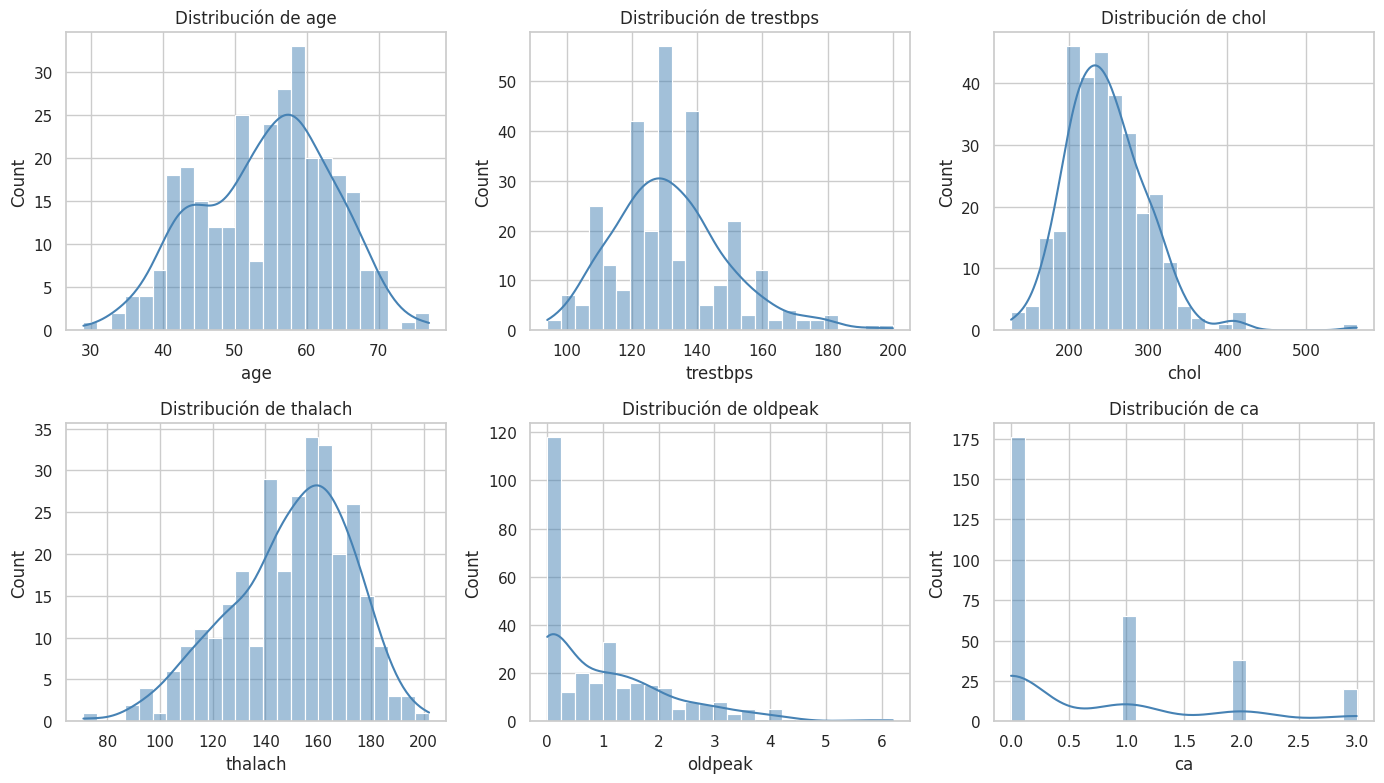

In [ ]:
# Variables numéricas continuas seleccionadas
# para el análisis de distribuciones

variables_numericas = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'ca'
]

# Histogramas y curvas de densidad
# para observar la distribución
# de cada variable numérica

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variables_numericas):

    # dropna() evita problemas
    # con valores faltantes

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=25,
        ax=ax,
        color='steelblue'
    )

    ax.set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

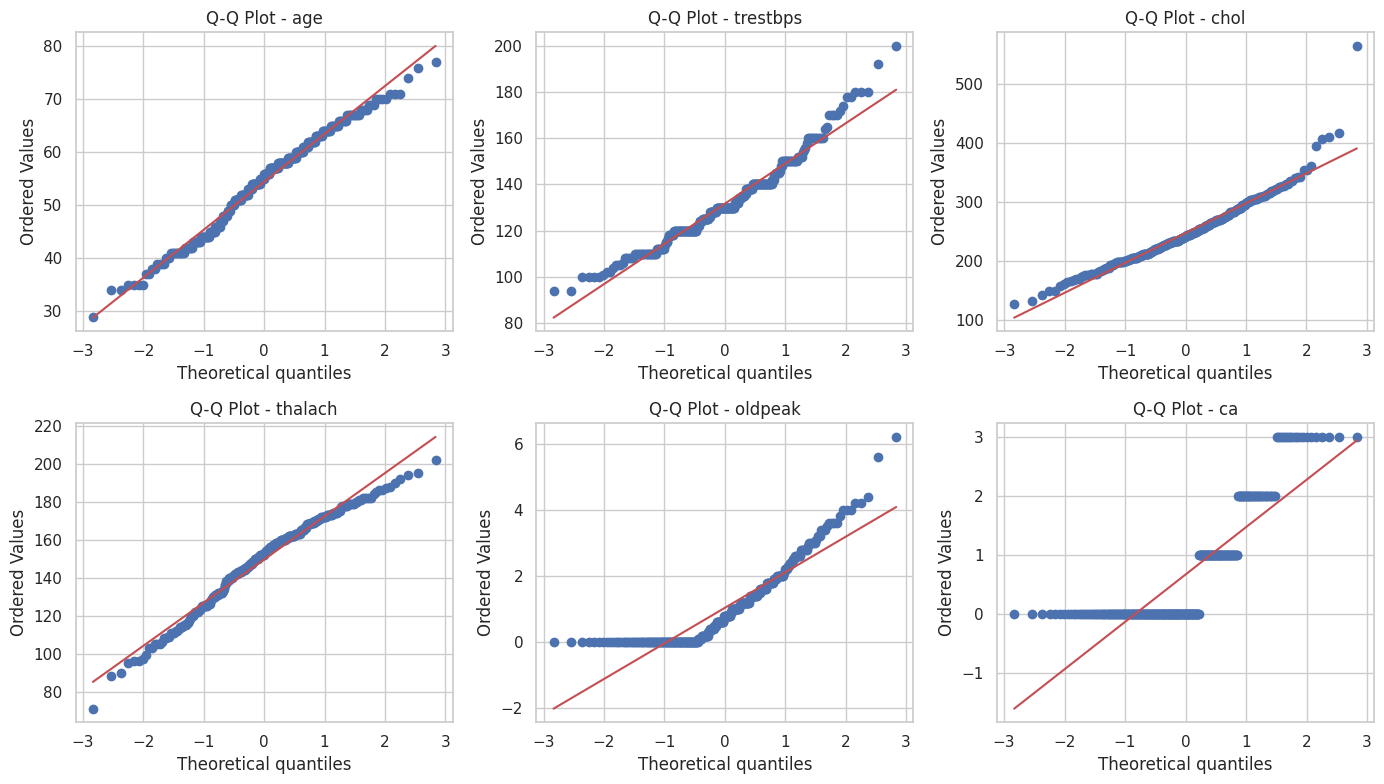

In [ ]:
# Q-Q Plot para evaluar qué tan cercana
# es la distribución de las variables
# respecto a una distribución normal

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variables_numericas):

    stats.probplot(
        df[col].dropna(),
        dist='norm',
        plot=ax
    )

    ax.set_title(f'Q-Q Plot - {col}')

plt.tight_layout()
plt.show()

En los Q-Q plots observamos que varias variables no siguen completamente una distribución normal. Algunas, como `oldpeak` y `ca`, presentan mayores desviaciones respecto a la línea diagonal, lo que puede indicar asimetría o un comportamiento discreto.

A continuación aplicamos la prueba de Shapiro-Wilk para evaluar la normalidad de forma estadística.

In [ ]:
# Prueba de Shapiro-Wilk para evaluar normalidad

# Hipótesis:
# H0 = la variable sigue una distribución normal
# H1 = la variable no sigue una distribución normal

# Si el p-valor es menor a 0.05,
# se rechaza la hipótesis nula.

resultados_shapiro = []

for col in variables_numericas:

    # La prueba retorna:
    # W = estadístico de prueba
    # p_valor = significancia

    W, p_valor = stats.shapiro(df[col].dropna())

    if p_valor < 0.05:
        decision = 'Rechaza H0 (no normal)'
    else:
        decision = 'No rechaza H0 (normal)'

    resultados_shapiro.append({
        'Variable': col,
        'W': round(W, 4),
        'p_valor': round(p_valor, 6),
        'Resultado': decision
    })

# Resultados de la prueba
shapiro_df = pd.DataFrame(resultados_shapiro)

shapiro_df

,Variable,W,p_valor,Resultado
0,age,0.9865,0.006069,Rechaza H0 (no normal)
1,trestbps,0.9665,0.000002,Rechaza H0 (no normal)
2,chol,0.9473,0.000000,Rechaza H0 (no normal)
3,thalach,0.9765,0.000070,Rechaza H0 (no normal)
4,oldpeak,0.8442,0.000000,Rechaza H0 (no normal)
5,ca,0.7187,0.000000,Rechaza H0 (no normal)


Todas las variables evaluadas presentan un p-valor menor a 0.05, por lo tanto rechazamos la hipótesis de normalidad. Esto significa que ninguna sigue una distribución completamente normal.

Estos resultados son importantes porque:

- Para el tratamiento de datos faltantes resulta más adecuado utilizar la mediana en lugar de la media.
- En el segundo entregable debemos tener cuidado con las técnicas que asumen normalidad en los datos.

## III. Detección y Tratamiento de Ausentes

### Conteo de nulos por columna

In [ ]:
# Conteo de valores faltantes por columna

nulos = df.isnull().sum()

# Porcentaje de nulos respecto
# al total de registros

porcentaje = (
    df.isnull().sum() / len(df) * 100
).round(2)

# Se crea una tabla resumen
# con la cantidad y porcentaje
# de datos faltantes

tabla_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje
})

# Se muestran únicamente
# las variables que presentan nulos

tabla_nulos = tabla_nulos[
    tabla_nulos['Nulos'] > 0
]

tabla_nulos

,Nulos,Porcentaje (%)
ca,4,1.32
thal,2,0.66


El dataset presenta muy pocos valores faltantes: 4 registros en `ca` y 2 en `thal`.

Como la cantidad de nulos es baja, no conviene eliminar filas completas, ya que perderíamos información útil. Por esa razón consideramos más adecuado aplicar técnicas de imputación.

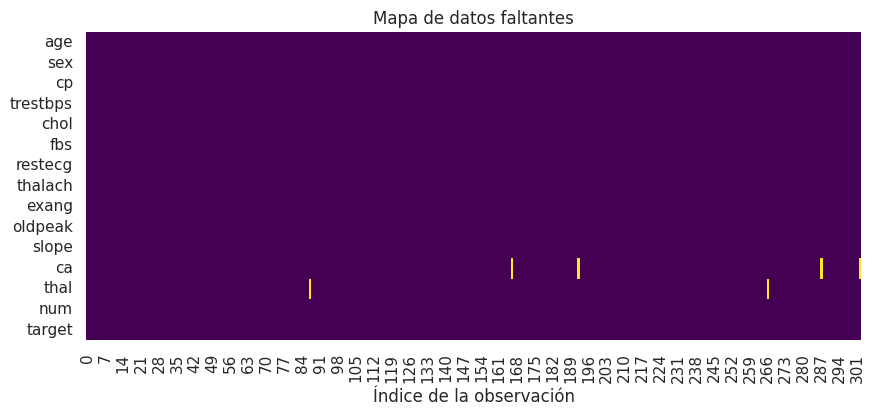

In [ ]:
# Visualización de los valores faltantes
# mediante un mapa de calor

plt.figure(figsize=(10, 4))

sns.heatmap(
    df.isnull().T,
    cbar=False,
    cmap='viridis'
)

plt.title('Mapa de datos faltantes')
plt.xlabel('Índice de la observación')

plt.show()

### Prueba de Rachas (Wald–Wolfowitz)

Esta prueba nos permite analizar si los valores faltantes aparecen de forma aleatoria dentro del dataset.

- **H₀:** los nulos aparecen aleatoriamente.
- **H₁:** existe un patrón en los nulos.

Para aplicarla transformamos la presencia de nulos en una secuencia binaria (1 = valor nulo, 0 = valor no nulo) y analizamos las "rachas", es decir, los cambios entre 0 y 1 a lo largo de la secuencia.

In [ ]:
# Implementación de la prueba de rachas
# de Wald-Wolfowitz

def prueba_rachas(secuencia):

    """
    Función para evaluar si una secuencia
    binaria presenta comportamiento aleatorio.

    1 = dato nulo
    0 = dato no nulo
    """

    seq = np.array(secuencia)

    # Cantidad de unos y ceros
    n1 = (seq == 1).sum()
    n2 = (seq == 0).sum()

    n = n1 + n2

    # Si toda la secuencia es igual
    # no se puede aplicar la prueba

    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, 0

    # Conteo de rachas
    # Una racha ocurre cuando cambia
    # el valor entre 0 y 1

    cambios = (seq[1:] != seq[:-1]).sum()

    rachas = 1 + cambios

    # Media y varianza esperada
    # bajo comportamiento aleatorio

    media_esperada = (
        (2 * n1 * n2) / n
    ) + 1

    varianza = (
        (2 * n1 * n2 * (2 * n1 * n2 - n))
        / (n**2 * (n - 1))
    )

    if varianza <= 0:
        return np.nan, np.nan, rachas

    # Estadístico Z

    z = (
        (rachas - media_esperada)
        / np.sqrt(varianza)
    )

    # p-valor bilateral

    p_valor = 2 * (
        1 - stats.norm.cdf(abs(z))
    )

    return z, p_valor, rachas


# Aplicación de la prueba
# sobre variables con nulos

resultados_rachas = []

for col in tabla_nulos.index:

    # Conversión a secuencia binaria
    # 1 = nulo
    # 0 = dato válido

    secuencia_binaria = (
        df[col]
        .isnull()
        .astype(int)
        .values
    )

    z, p_valor, rachas = prueba_rachas(
        secuencia_binaria
    )

    if p_valor >= 0.05:
        decision = 'Aleatorio (MCAR)'
    else:
        decision = 'No aleatorio (MAR/MNAR)'

    resultados_rachas.append({
        'Variable': col,
        'Rachas': rachas,
        'Z': round(z, 4),
        'p_valor': round(p_valor, 4),
        'Resultado': decision
    })

# Resultados finales

pd.DataFrame(resultados_rachas)

,Variable,Rachas,Z,p_valor,Resultado
0,ca,8,-2.1068,0.0351,No aleatorio (MAR/MNAR)
1,thal,5,0.1335,0.8938,Aleatorio (MCAR)


Los resultados muestran que los nulos de la variable `ca` presentan un patrón no aleatorio (p < 0.05). Esto sugiere que esos datos faltantes podrían estar relacionados con alguna característica del dataset y no ocurrieron al azar.

En cambio, los nulos de `thal` presentan un comportamiento más aleatorio.

Por este motivo, para `ca` puede ser más adecuado usar una técnica de imputación más avanzada que una imputación simple por mediana.

## IV. Tratamiento de Outliers — Método IQR

Para identificar valores atípicos utilizamos el método IQR (rango intercuartílico), que consiste en:

- Calcular el primer cuartil (Q1) y el tercer cuartil (Q3).
- Obtener el rango intercuartílico: IQR = Q3 − Q1.
- Definir los límites: inferior = Q1 − 1.5·IQR y superior = Q3 + 1.5·IQR.

Los valores que queden por fuera de esos límites se consideran posibles outliers.

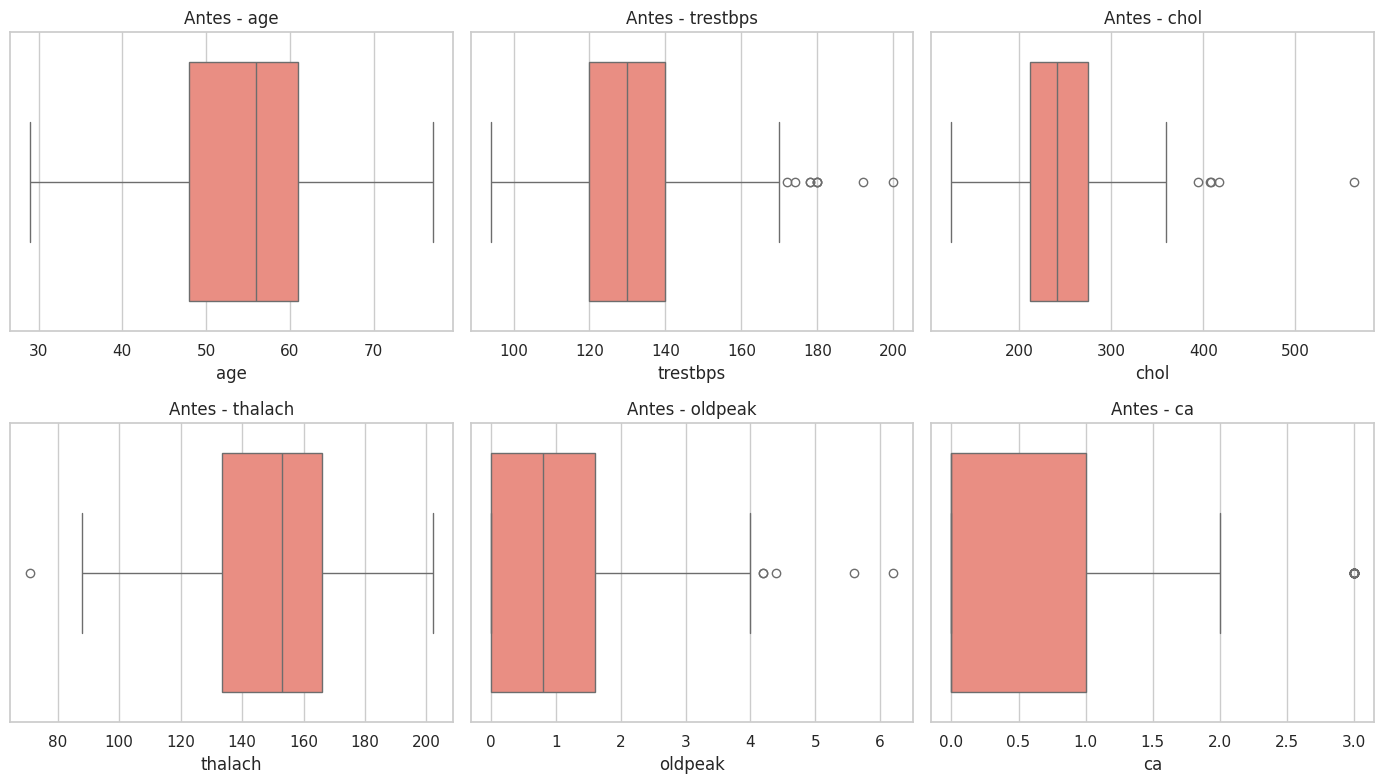

In [ ]:
# Boxplots antes del tratamiento
# de valores atípicos

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variables_numericas):

    sns.boxplot(
        x=df[col].dropna(),
        ax=ax,
        color='salmon'
    )

    ax.set_title(f'Antes - {col}')

plt.tight_layout()
plt.show()

In [ ]:
# Cálculo de límites usando IQR
# y aplicación de capping

df_sin_outliers = df.copy()

resumen_outliers = []

for col in variables_numericas:

    # Cálculo de cuartiles

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Rango intercuartílico

    IQR = Q3 - Q1

    # Límites inferior y superior

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Identificación de outliers

    es_outlier = (
        (df[col] < limite_inf) |
        (df[col] > limite_sup)
    )

    n_outliers = es_outlier.sum()

    # Aplicación de capping
    # Los valores extremos se reemplazan
    # por los límites calculados

    df_sin_outliers[col] = (
        df_sin_outliers[col]
        .clip(
            lower=limite_inf,
            upper=limite_sup
        )
    )

    resumen_outliers.append({
        'Variable': col,
        'Limite inferior': round(limite_inf, 2),
        'Limite superior': round(limite_sup, 2),
        'Cantidad outliers': int(n_outliers)
    })

# Resumen de outliers detectados

pd.DataFrame(resumen_outliers)

,Variable,Limite inferior,Limite superior,Cantidad outliers
0,age,28.50,80.50,0
1,trestbps,90.00,170.00,9
2,chol,115.00,371.00,5
3,thalach,84.75,214.75,1
4,oldpeak,-2.40,4.00,5
5,ca,-1.50,2.50,20


**Justificación del tratamiento aplicado.** Detectamos aproximadamente 40 valores atípicos en el dataset. Eliminar esos registros representaría una pérdida importante de información, teniendo en cuenta que el dataset solo contiene 303 observaciones.

Además, algunos valores extremos —como niveles altos de colesterol— podrían corresponder a casos reales y no necesariamente a errores. Por eso decidimos aplicar *capping*, que reemplaza los valores extremos por los límites calculados con IQR. Así conservamos todos los registros y reducimos el impacto de los outliers.

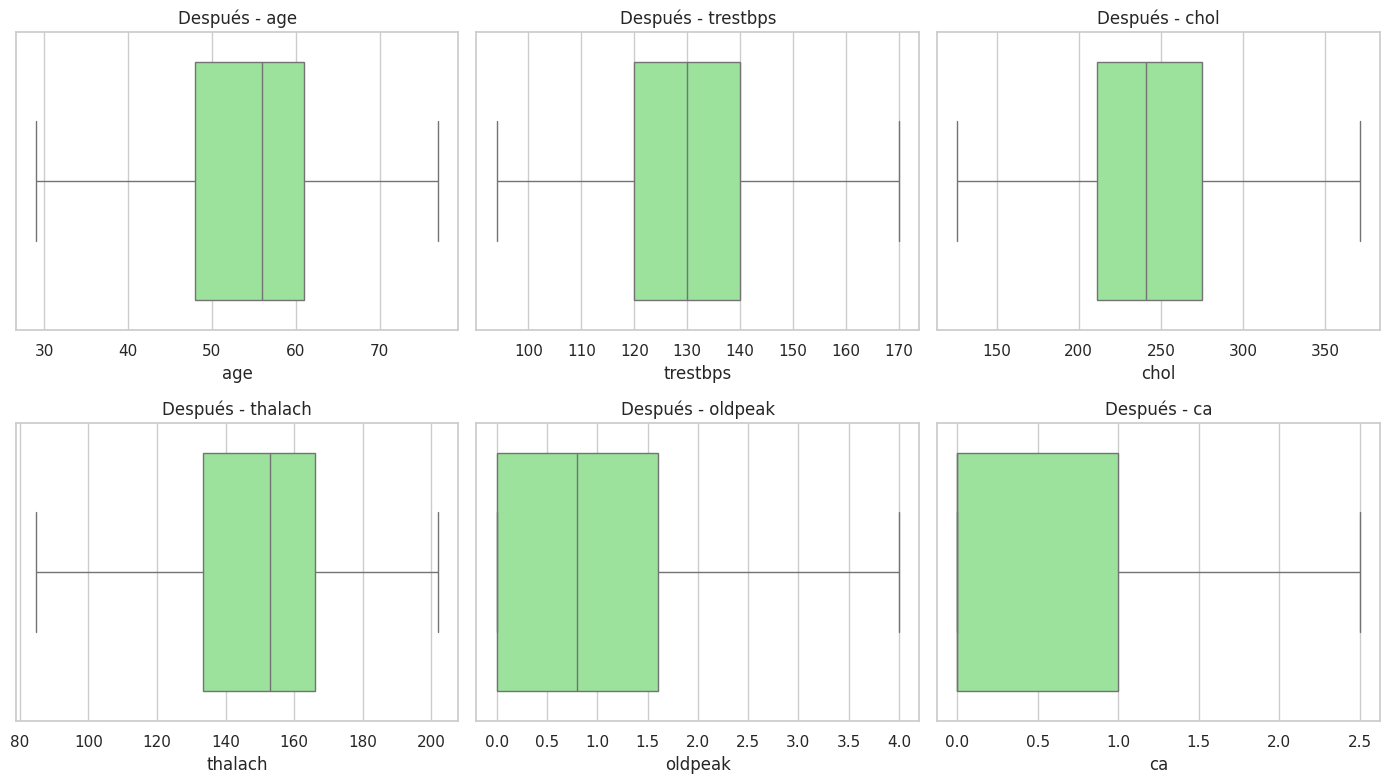

In [ ]:
# Boxplots después de aplicar capping

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variables_numericas):

    sns.boxplot(
        x=df_sin_outliers[col].dropna(),
        ax=ax,
        color='lightgreen'
    )

    ax.set_title(f'Después - {col}')

plt.tight_layout()
plt.show()

## V. Imputación Comparativa

En esta sección comparamos dos técnicas de imputación aplicadas sobre la variable `ca`, que es la que presenta mayor cantidad de valores faltantes:

1. **Imputación simple por mediana:** reemplaza los nulos con el valor central de la variable.
2. **Imputación por regresión:** utiliza la información de las demás variables para estimar los valores faltantes.

In [ ]:
# Técnica 1:
# Imputación simple utilizando la mediana

df_mediana = df_sin_outliers.copy()

# Se crea el imputador con estrategia median

imputador_simple = SimpleImputer(
    strategy='median'
)

# Aplicación de la imputación
# sobre variables numéricas

df_mediana[variables_numericas] = (
    imputador_simple.fit_transform(
        df_mediana[variables_numericas]
    )
)

# Verificación de nulos restantes
# en la variable "ca"

print(
    'Nulos en ca después de imputación por mediana:',
    df_mediana['ca'].isnull().sum()
)

Nulos en ca después de imputación por mediana: 0


In [ ]:
# Técnica 2:
# Imputación por regresión
# utilizando IterativeImputer

# Esta técnica estima los valores faltantes
# utilizando relaciones entre variables.

df_regresion = df_sin_outliers.copy()

# Se utiliza BayesianRidge
# como modelo de predicción

imputador_regresion = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    random_state=42  # permite reproducibilidad
)

# Aplicación de la imputación
# sobre las variables numéricas

df_regresion[variables_numericas] = (
    imputador_regresion.fit_transform(
        df_regresion[variables_numericas]
    )
)

# Verificación de nulos restantes
# en la variable "ca"

print(
    'Nulos en ca después de imputación por regresión:',
    df_regresion['ca'].isnull().sum()
)

Nulos en ca después de imputación por regresión: 0


In [ ]:
# Comparación estadística de la variable "ca"
# en las diferentes versiones del dataset

comparacion = pd.DataFrame({

    'Original (con nulos)': (
        df['ca'].describe()
    ),

    'Imputación mediana': (
        df_mediana['ca'].describe()
    ),

    'Imputación regresión': (
        df_regresion['ca'].describe()
    )

})

# Se redondean los resultados
# para facilitar la lectura

comparacion.round(4)

,Original (con nulos),Imputación mediana,Imputación regresión
count,299.0000,303.0000,303.0000
mean,0.6722,0.6304,0.6351
std,0.9374,0.8566,0.8547
min,0.0000,0.0000,-0.0478
25%,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000
75%,1.0000,1.0000,1.0000
max,3.0000,2.5000,2.5000


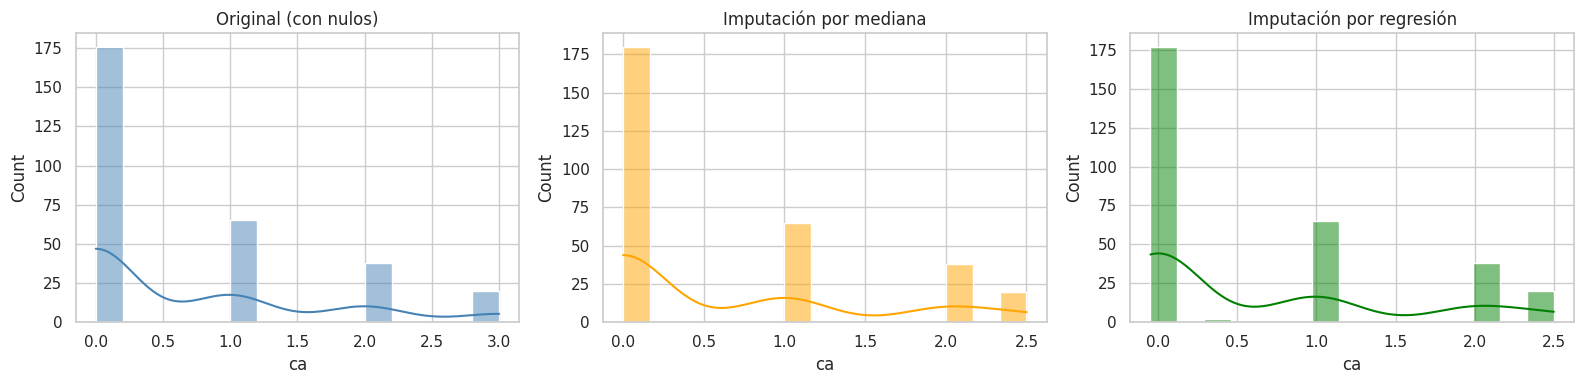

In [ ]:
# Comparación visual de las distribuciones
# después de aplicar cada técnica
# de imputación

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución original

sns.histplot(
    df['ca'].dropna(),
    kde=True,
    bins=15,
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Original (con nulos)')

# Imputación por mediana

sns.histplot(
    df_mediana['ca'],
    kde=True,
    bins=15,
    ax=axes[1],
    color='orange'
)

axes[1].set_title('Imputación por mediana')

# Imputación por regresión

sns.histplot(
    df_regresion['ca'],
    kde=True,
    bins=15,
    ax=axes[2],
    color='green'
)

axes[2].set_title('Imputación por regresión')

plt.tight_layout()
plt.show()

**Conclusión de la comparación.** La imputación por mediana tiende a concentrar aún más los valores alrededor de la mediana, generando una distribución menos natural.

En cambio, la imputación por regresión estima los valores considerando la relación entre las variables del dataset, lo que produce resultados más coherentes con el comportamiento general de los datos.

Por esa razón, para el segundo entregable trabajamos con el dataset imputado mediante regresión.

## Cierre

### Matriz de correlación del dataset preprocesado

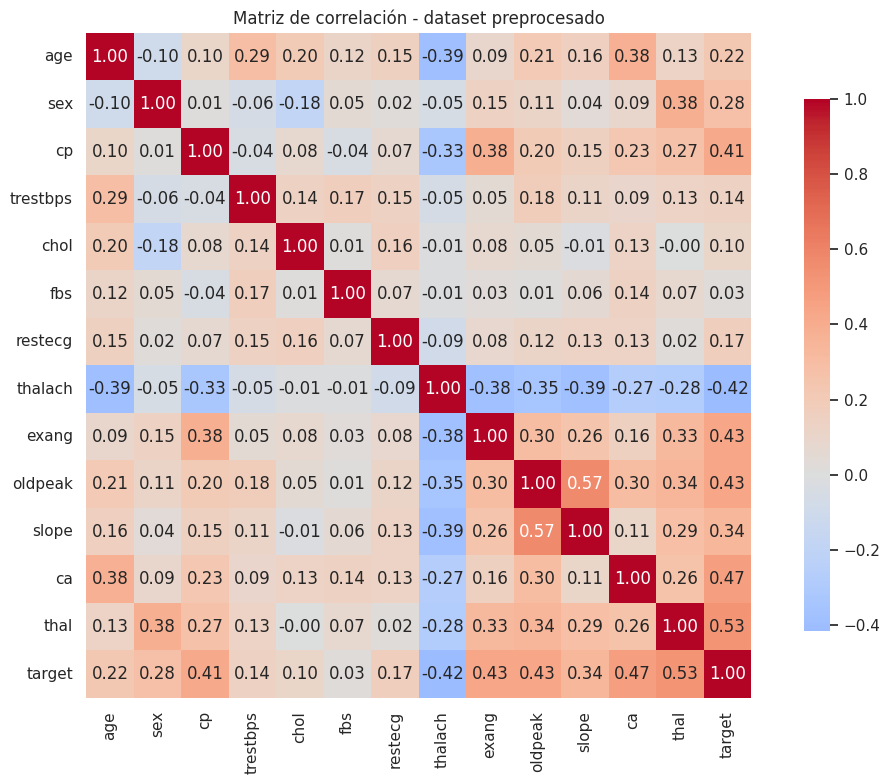

In [ ]:
# Matriz de correlación final
# del dataset preprocesado

plt.figure(figsize=(11, 8))

# Se excluye la variable original "num"
# porque ya se creó la variable binaria "target"

correlacion = (
    df_regresion
    .drop(columns=['num'])
    .corr()
)

# Mapa de calor de correlaciones

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title(
    'Matriz de correlación - dataset preprocesado'
)

plt.tight_layout()
plt.show()